# Content-based recommendations

A user asks a film catalogue: **“I liked the films I have already rated. What should I watch next?”** The catalogue must choose a short list from the films this user has not rated yet. It knows the user's ratings and has descriptive information about every film, such as its genres.

The recommendation should reflect this user's taste, not just the catalogue's overall popularity. A simple approach is to find the attributes shared by the films the user liked and use them to score the remaining films.

This is a **content-based recommender**. We will use MovieLens 100K to represent genres with one-hot vectors, build a profile from positive ratings, rank unseen films, and evaluate the recommendations on ratings made later.

## A catalogue that describes itself

### a. Let's start with the films

Before recommending anything, we need to know what an item looks like. MovieLens gives us a list of films and, for each film, a set of genres such as Comedy, Drama, or Sci-Fi.

For this first lesson, genres will be enough. We will leave the film titles and the more complicated text processing for a later exercise.

In [23]:
from collections import Counter, defaultdict
import csv
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATASET_DIR = Path(".cache/ml-100k")
archive_path = DATASET_DIR.parent / "ml-100k.zip"

if not DATASET_DIR.exists():
    DATASET_DIR.parent.mkdir(exist_ok=True)
    if not archive_path.exists():
        print("Downloading MovieLens 100K...")
        urllib.request.urlretrieve(
            "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
            archive_path,
        )
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(DATASET_DIR.parent)

The dataset is provided by the [GroupLens research group](https://grouplens.org/datasets/movielens/100k/). It contains 100,000 ratings made by 943 users on 1,682 films.

The files are downloaded into `.cache`, which is ignored by this project.

In [24]:
with (DATASET_DIR / "u.genre").open(encoding="latin-1") as file:
    GENRE_NAMES = tuple(
        line.split("|", 1)[0] for line in file if line.strip()
    )

items = {}
with (DATASET_DIR / "u.item").open(encoding="latin-1", newline="") as file:
    for row in csv.reader(file, delimiter="|"):
        item_id = int(row[0])
        items[item_id] = (row[1], row[5 : 5 + len(GENRE_NAMES)])

ITEM_IDS = np.array(sorted(items), dtype=int)
item_titles = {item_id: items[item_id][0] for item_id in ITEM_IDS}
GENRE_MATRIX = np.array(
    [items[item_id][1] for item_id in ITEM_IDS],
    dtype=float,
)
ITEM_INDEX = {item_id: index for index, item_id in enumerate(ITEM_IDS)}

### b. Let's look at one film

A genre vector is just a row of zeros and ones. A one means that the film belongs to that genre. It is not very glamorous, but it is wonderfully easy to inspect.

In [25]:
film_vector = GENRE_MATRIX[ITEM_INDEX[1]]
film_genres = [
    genre for genre, present in zip(GENRE_NAMES, film_vector) if present
]

print(f"Title: {item_titles[1]}")
print(f"Genres: {film_genres}")
print(f"Vector: {film_vector.astype(int)}")

Title: Toy Story (1995)
Genres: ['Animation', "Children's", 'Comedy']
Vector: [0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Finding films that look alike

### a. What does "similar" mean?

Suppose one film is tagged `Comedy` and `Romance`, and another film has exactly the same tags. They should be considered similar. A film tagged only `Horror` should be less similar.

We will compare two vectors with **cosine similarity**. It returns a value close to 1 when the vectors point in the same direction, and a value close to 0 when they have little in common.

In [26]:
def cosine_similarity(vector, matrix):
    denominator = np.linalg.norm(vector) * np.linalg.norm(matrix, axis=1)
    return np.divide(
        matrix @ vector,
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator > 0,
    )


def similar_items(item_id, k=10):
    candidate_indices = np.flatnonzero(ITEM_IDS != item_id)
    scores = cosine_similarity(
        GENRE_MATRIX[ITEM_INDEX[item_id]],
        GENRE_MATRIX[candidate_indices],
    )
    top = np.argsort(-scores, kind="stable")[:k]
    return [
        (int(ITEM_IDS[candidate_indices[index]]), float(scores[index]))
        for index in top
    ]


toy_story_id = next(
    item_id for item_id, title in item_titles.items() if title == "Toy Story (1995)"
)
print(f"Films similar to {item_titles[toy_story_id]}:")
for item_id, score in similar_items(toy_story_id):
    print(f"{score:.3f}  {item_titles[item_id]}")

Films similar to Toy Story (1995):
1.000  Aladdin and the King of Thieves (1996)
0.866  Aladdin (1992)
0.866  Goofy Movie, A (1995)
0.816  Santa Clause, The (1994)
0.816  Home Alone (1990)
0.816  Aristocats, The (1970)
0.816  D3: The Mighty Ducks (1996)
0.816  Love Bug, The (1969)
0.816  Wrong Trousers, The (1993)
0.816  Grand Day Out, A (1992)


The recommender has not looked at any user yet. It is only answering this question:

> Which films have a genre description close to this film's description?

That is already a recommendation, but it is the same recommendation for everybody. We need one more ingredient: the person looking at the screen.

## Building a profile for one user

### a. Let's see what the ratings contain

MovieLens stores one row per interaction: a user, a film, a rating, and a timestamp. The timestamp matters because it lets us distinguish what the user knew before a recommendation from what happened later.

In [27]:
ratings = np.loadtxt(DATASET_DIR / "u.data", dtype=np.int64)
ratings = ratings[np.argsort(ratings[:, 3], kind="stable")]

sample_user_id = 1
sample_events = ratings[ratings[:, 0] == sample_user_id][:8]
print(f"First ratings from user {sample_user_id}:")
for _, item_id, rating, _ in sample_events:
    print(f"{int(rating)}/5  {item_titles[int(item_id)]}")

First ratings from user 1:
5/5  Monty Python and the Holy Grail (1974)
5/5  Empire Strikes Back, The (1980)
5/5  Jean de Florette (1986)
4/5  Reservoir Dogs (1992)
5/5  Dead Poets Society (1989)
5/5  Manon of the Spring (Manon des sources) (1986)
4/5  Godfather: Part II, The (1974)
5/5  Postino, Il (1994)


### b. Turning liked films into a user profile

Let us call a rating of 4 or 5 a positive signal. We make the user profile by averaging the genre vectors of those liked films. A rating of 5 gets a little more weight than a rating of 4.

In plain language:

`user profile = weighted average of the genres of liked films`

The recommendation score for a new film is then the cosine similarity between that profile and the film's genre vector.

In [28]:
def build_user_profile(history):
    liked = [
        (item_id, rating - 3)
        for item_id, rating in history
        if rating >= 4
    ]
    if not liked:
        return np.zeros(len(GENRE_NAMES))

    item_ids, weights = zip(*liked)
    return np.average(
        GENRE_MATRIX[[ITEM_INDEX[item_id] for item_id in item_ids]],
        axis=0,
        weights=weights,
    )


def recommend_content_based(history, k=10):
    profile = build_user_profile(history)
    if not np.any(profile):
        return []

    seen = {item_id for item_id, _ in history}
    candidate_ids = np.setdiff1d(ITEM_IDS, list(seen))
    if not candidate_ids.size:
        return []

    candidate_indices = [ITEM_INDEX[item_id] for item_id in candidate_ids]
    scores = cosine_similarity(profile, GENRE_MATRIX[candidate_indices])
    top = np.argsort(-scores, kind="stable")[:k]
    return [int(candidate_ids[index]) for index in top]


sample_history = [
    (int(item_id), int(rating)) for _, item_id, rating, _ in sample_events
]
print("Films liked by the example user:")
for item_id, rating in sample_history:
    if rating >= 4:
        print(f"{rating}/5  {item_titles[item_id]}")

print("\nRecommendations from the profile:")
for item_id in recommend_content_based(sample_history):
    print(item_titles[item_id])

Films liked by the example user:
5/5  Monty Python and the Holy Grail (1974)
5/5  Empire Strikes Back, The (1980)
5/5  Jean de Florette (1986)
4/5  Reservoir Dogs (1992)
5/5  Dead Poets Society (1989)
5/5  Manon of the Spring (Manon des sources) (1986)
4/5  Godfather: Part II, The (1974)
5/5  Postino, Il (1994)

Recommendations from the profile:
Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)
Dead Man Walking (1995)
Mr. Holland's Opus (1995)
White Balloon, The (1995)
Antonia's Line (1995)
Belle de jour (1967)
Nadja (1994)
Exotica (1994)
Madness of King George, The (1994)
Priest (1994)


## Can we test whether this works?

### a. A small offline experiment

We do not have a log saying which films MovieLens showed to each user. We therefore cannot measure clicks on recommendations directly. We can still ask a useful question:

> If we had stopped the clock earlier, could our recommender have predicted the films this user liked later?

This is an **offline replay**. We reveal the user's history one event at a time, as if the future rating had just arrived.

### b. The rules of the replay

1. Sort the ratings by timestamp.
2. Use the first 80% of the timeline as training history.
3. Keep users who already have at least three liked films.
4. Recommend 10 unseen films before revealing each future rating.
5. Call a future rating of 4 or 5 a liked film.
6. Count a hit when that liked film appears in the top 10.
7. Reveal the rating and update the user's history.

The metric we will plot is **HitRate@10**: the proportion of future liked films that appeared in the recommendations.

In [29]:
split_timestamp = ratings[int(len(ratings) * 0.8), 3]
train_ratings = ratings[ratings[:, 3] < split_timestamp]
test_ratings = ratings[ratings[:, 3] >= split_timestamp]

train_history_by_user = defaultdict(list)
for user_id, item_id, rating, _ in train_ratings:
    train_history_by_user[int(user_id)].append((int(item_id), int(rating)))

future_positive_users = set(test_ratings[test_ratings[:, 2] >= 4, 0].astype(int))
eligible_users = {
    user_id
    for user_id, history in train_history_by_user.items()
    if sum(rating >= 4 for _, rating in history) >= 3
    and user_id in future_positive_users
}
test_events = test_ratings[
    np.isin(test_ratings[:, 0], list(eligible_users))
]

positive_items = train_ratings[train_ratings[:, 2] >= 4, 1].astype(int)
popular_item_ids = [
    item_id for item_id, _ in Counter(positive_items).most_common()
]
popular_set = set(popular_item_ids)
POPULAR_ITEM_IDS = np.array(
    popular_item_ids
    + [int(item_id) for item_id in ITEM_IDS if item_id not in popular_set],
    dtype=int,
)

### c. Three recommenders to compare

A metric is more useful when it has a reference point. We will compare three simple rules:

- `Random` chooses unseen films at random.
- `Popular` recommends films that received many positive ratings in the training period.
- `Content-based` uses the user's genre profile.

The popular recommender is deliberately simple. If our cleverer method cannot beat it, we should know that before celebrating.

In [30]:
def recommend_popular(history, k=10):
    seen = {item_id for item_id, _ in history}
    return [int(item_id) for item_id in POPULAR_ITEM_IDS if item_id not in seen][:k]


def recommend_random(history, rng, k=10):
    seen = {item_id for item_id, _ in history}
    candidates = np.setdiff1d(ITEM_IDS, list(seen))
    return rng.choice(
        candidates,
        size=min(k, candidates.size),
        replace=False,
    ).astype(int).tolist()

### d. Let the replay begin

At each step we make the recommendation first. Only afterwards do we reveal the rating. This order is important. If we used the future rating before recommending, the experiment would quietly give the answer to the model.

In [31]:
histories = {
    user_id: list(train_history_by_user[user_id]) for user_id in eligible_users
}
rng = np.random.default_rng(21)
methods = ("Random", "Popular", "Content-based")
hit_totals = dict.fromkeys(methods, 0)
cumulative_hit_rates = {method: [] for method in methods}
positive_events_revealed = 0

for row in test_events:
    user_id, item_id, rating, _ = (int(value) for value in row)
    history = histories[user_id]
    recommendations = {
        "Random": recommend_random(history, rng),
        "Popular": recommend_popular(history),
        "Content-based": recommend_content_based(history),
    }

    if rating >= 4:
        positive_events_revealed += 1
        for method in methods:
            hit_totals[method] += item_id in recommendations[method]
            cumulative_hit_rates[method].append(
                hit_totals[method] / positive_events_revealed
            )

    history.append((item_id, rating))

print(f"Future liked films evaluated: {positive_events_revealed:,}")
for method in methods:
    rate = hit_totals[method] / positive_events_revealed
    print(f"{method:>14}: HitRate@10 = {rate:.3f}")

Future liked films evaluated: 1,582
        Random: HitRate@10 = 0.007
       Popular: HitRate@10 = 0.102
 Content-based: HitRate@10 = 0.030


The final number tells us who won at the end. The curve tells us something more interesting: how the estimate behaves as more future interactions are revealed.

This is the same visual trick as in chapter 1. After every new positive event, we store the cumulative average and draw the list of averages.

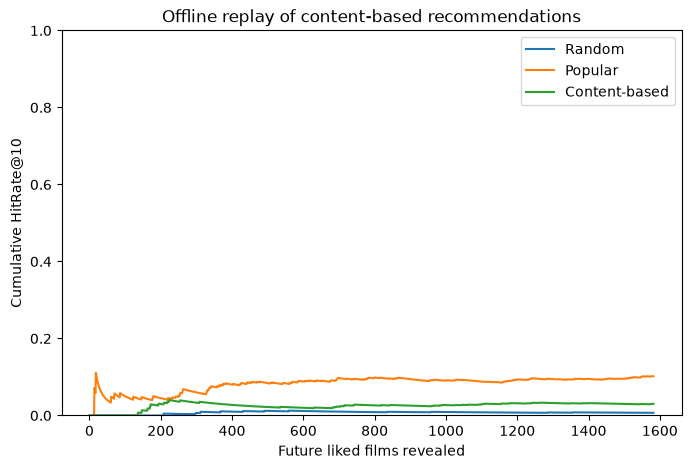

In [32]:
steps = np.arange(1, positive_events_revealed + 1)

plt.figure(figsize=(8, 5))
for method in methods:
    plt.plot(
        steps,
        cumulative_hit_rates[method],
        label=method,
    )

plt.xlabel("Future liked films revealed")
plt.ylabel("Cumulative HitRate@10")
plt.ylim(0, 1)
plt.title("Offline replay of content-based recommendations")
plt.legend()
plt.show()

## What did we actually measure?

A hit means that a film the user later rated 4 or 5 was present in our top 10. It does **not** prove that the user would have clicked the film, watched it, or rated it highly if we had shown it. MovieLens does not contain the complete list of films displayed to each user.

There is another important detail: the content-based recommender only uses the current user's history and the films' genres. It does not use another user's ratings. That is the line separating this chapter from collaborative filtering in chapter 3.

## Your turn

The recommender works, but it is still a small first version. Try these changes one at a time:

- Change the definition of a liked film from `rating >= 4` to `rating == 5`.
- Compare `HitRate@5`, `HitRate@10`, and `HitRate@20`.
- Give disliked films a negative weight instead of ignoring them.
- Replace the genre vector with a TF-IDF vector built from the film titles.
- Use each user's last five ratings as the test set instead of a global time split.
- Add a fourth curve for a recommender that always suggests the single most popular film.

The most useful exercise is probably the last one: a recommender should be compared with a baseline, not with our imagination.

## In summary

- A content-based recommender represents each item with features that describe its content.
- A user profile can be built by averaging the features of items that user liked.
- Cosine similarity lets us rank unseen items by their resemblance to the profile.
- A chronological offline replay reveals future ratings only after making a recommendation.
- Cumulative HitRate@10 shows how the evaluation behaves as more feedback arrives.
- The method can recommend a new item when its genres are known, even if nobody has rated that item yet. That is its main advantage over methods that need interaction history.